# Filtering TM/TR CDF plot (tvkern 0617 dsub)

Based on 0615. The standalone EP/ER cell is merged into the DR cell: the WD bars are drawn once,
with DR on the right axis and per-timer eps_P/eps_R threshold arrows on top of each bar.

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
DATE_BASE = "20260616"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
DEFAULT_SHUFFLE_SELECT = "shuffle2"
HOST_SHUFFLE_SELECTS = {
    # Default: every host uses DEFAULT_SHUFFLE_SELECT.
    # Override one host manually, for example:
    # "c920bn3": "shuffle2",
}
SHUFFLE_SELECT = DEFAULT_SHUFFLE_SELECT
TR_MARKER_MAX = 100

# Previous 20260615 roots, kept for audit and intentionally not used:
# - 20260615-141629-tvkern-dsub: older dsub path; no script-level run start/end timestamp and command, older NSPV handling, KP wtime/papix6 risk.
# - 20260615-193641/214141/214143-tvkern-dsub-logfix: improved logging, but KP920B cgt regression: dsub/sub work was wrapped into a return-value helper and attached to sink.
# /astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/output_tvkern_filt_dsub/20260615-193641-tvkern-dsub-logfix/shuffle0
# /astrum/home/hpchzy/code/data/20260615/camd9554n1/output_tvkern_filt_dsub/20260615-214141-tvkern-dsub-logfix/shuffle0
# /astrum/home/hpchzy/code/data/20260615/c920bn3/output_tvkern_filt_dsub/20260615-214143-tvkern-dsub-logfix/shuffle0

# Previous 20260616 07:xx inline roots, kept for bug audit and intentionally not used:
# - commit: c58857265d9e6468b6d8edface53d7c75d68795c
# - data:
#   /astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_tvkern_filt_dsub/20260616-070704-tvkern-dsub-0615
#   /astrum/home/hpchzy/code/data/20260616/camd9554n1/output_tvkern_filt_dsub/20260616-070706-tvkern-dsub-0615
#   /astrum/home/hpchzy/code/data/20260616/c920bn3/output_tvkern_filt_dsub/20260616-070709-tvkern-dsub-0615
# - bug/reason: tvkern sub_loop/dsub_loop and stencil dsub_loop were still inline-capable; this made the loop-call boundary optimizer-dependent.
#   The 09:xx noinline rerun below uses commit 80547a23841ee40feb8a805993f91da34a94fa66 to force a stable noinline boundary.

# Explicit timestamp roots for the active 09:xx noinline rerun. Do not append shuffle here;
# per-host shuffle selection is handled by HOST_SHUFFLE_SELECTS / DEFAULT_SHUFFLE_SELECT.
RUN_ROOT_OVERRIDES = {
    "cgnr6760pn2": Path("/astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_tvkern_filt_dsub/20260616-082701-tvkern-dsub-noinline-0615"),
    "camd9554n1": Path("/astrum/home/hpchzy/code/data/20260616/camd9554n1/output_tvkern_filt_dsub/20260616-082707-tvkern-dsub-noinline-0615"),
    "c920bn3": Path("/astrum/home/hpchzy/code/data/20260616/c920bn3/output_tvkern_filt_dsub/20260616-082713-tvkern-dsub-noinline-0615"),
}


def shuffle_for_host(host):
    return HOST_SHUFFLE_SELECTS.get(host, DEFAULT_SHUFFLE_SELECT)


def latest_run_root(host):
    shuffle_select = shuffle_for_host(host)
    if host in RUN_ROOT_OVERRIDES:
        return RUN_ROOT_OVERRIDES[host] / shuffle_select
    base = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/{host}/output_tvkern_filt_dsub")
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / shuffle_select
        if root.exists():
            return root
    return base / "REPLACE_TIMESTAMP-tvkern-dsub" / shuffle_select

RUN_ROOTS = [latest_run_root(host).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join([f"{host}-{shuffle_for_host(host)}" for host in HOST_ORDER])

QUANTILE_DROP = 0.99
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#e377c2',
    'cntvcto': '#e377c2',
}

KERNEL_LABELS = {"tvkern": "tvkern"}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)


/astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_tvkern_filt_dsub/20260616-082701-tvkern-dsub-noinline-0615/shuffle2
/astrum/home/hpchzy/code/data/20260616/camd9554n1/output_tvkern_filt_dsub/20260616-082707-tvkern-dsub-noinline-0615/shuffle2
/astrum/home/hpchzy/code/data/20260616/c920bn3/output_tvkern_filt_dsub/20260616-082713-tvkern-dsub-noinline-0615/shuffle2
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']


In [4]:
def parse_filt_dir(path):
    name = path.name
    known_timers = sorted(TIMER_LABELS, key=len, reverse=True)
    for timer in known_timers:
        patterns = [
            rf'(?P<kernel>tvkern)_{re.escape(timer)}_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<ratio>[0-9.]+)_nsamp(?P<nsamp>\d+)_filt$',
            rf'(?P<kernel>tvkern)_{re.escape(timer)}_np(?P<np>\d+)_size(?P<size>\d+)_filt$',
        ]
        for pat in patterns:
            m = re.match(pat, name)
            if m:
                d = m.groupdict()
                d['timer'] = timer
                d['np'] = int(d['np'])
                d['size'] = int(d['size'])
                d['ratio'] = float(d.get('ratio') or np.nan)
                d['nsamp'] = int(d.get('nsamp') or 0)
                return d
    return None


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    return df['ns'].dropna().to_numpy()


def read_hist(hist_file):
    """Read tr_hist.csv / tm_hist.csv as step-function CDF.

    Format: each row is (left_edge, prob) where prob is the probability mass
    for the bin [left_edge, next_left_edge). The last row has prob=0 and
    serves as the right boundary sentinel.

    Returns a DataFrame with columns [ns, prob, cdf] suitable for step-plot:
      - ns is the LEFT edge of each bin (where the CDF step occurs)
      - cdf is the cumulative probability AFTER adding this bin's mass
      - A leading row with cdf=0 is prepended so the step starts visibly
      - The sentinel right-boundary row is kept so the last horizontal
        segment extends to the correct right edge.
    """
    df = pd.read_csv(hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    # Normalize by sum of non-sentinel prob (sentinel pr=0 contributes 0)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # Piecewise-linear CDF: cdf[i] = cumulative probability at LEFT edge of bin i
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        tm_hist_file = filt_dir / 'tm_hist.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tm_hist_file': tm_hist_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)


entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
entries.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
print(f'entries: {len(entries)}')

entries = entries[(entries['timer'] != 'cntvct') & (entries['timer'] != 'tsc_native')]
entries['timer'] = entries['timer'].replace('cntvcto', 'cntvct')
entries.head(20)


entries: 396


,kernel,np,size,ratio,nsamp,timer,host,data_folder,shuffle,filt_dir,tm_file,tm_hist_file,tr_hist_file
264,tvkern,64,0,0.5,10222,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
308,tvkern,64,0,0.5,10222,cntvct,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
330,tvkern,64,0,0.5,10411,papi,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
352,tvkern,64,0,0.5,10440,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
374,tvkern,64,0,0.5,10223,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
265,tvkern,64,0,0.8,10223,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
309,tvkern,64,0,0.8,10222,cntvct,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
331,tvkern,64,0,0.8,10425,papi,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
353,tvkern,64,0,0.8,10454,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...
375,tvkern,64,0,0.8,10237,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260616/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...,/astrum/home/hpchzy/code/data/20260616/c920bn3...


# ER/EP/Wasserstein summary


In [5]:
def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def wd_to_min(hist_file):
    df = read_hist(hist_file)
    if df.empty:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['prob'].to_numpy(dtype=float)
    if pr.sum() <= 0:
        return np.nan
    return np.sum(np.abs(ns - ns.min()) * pr) / pr.sum()


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for _, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    summary_rows.append({
        **row.to_dict(),
        'ep': read_float_file(filt_folder / 'ep.out'),
        'er': read_float_file(filt_folder / 'er.out'),
        'wd': read_float_file(filt_folder / 'wd.out'),
        'tm_wd_to_min': wd_to_min(filt_folder / 'tm_hist.csv'),
        'tr_wd_to_min': wd_to_min(filt_folder / 'tr_hist.csv'),
        'tr_seq': sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None,
        'tm_seq': sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None,
    })

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df['timer_label'] = df['timer'].map(TIMER_LABELS).fillna(df['timer'])
df['kernel_label'] = df['kernel'].map(KERNEL_LABELS).fillna(df['kernel'])
df.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
df[['host', 'kernel', 'timer', 'np', 'size', 'ratio', 'nsamp', 'ep', 'er', 'wd', 'tm_wd_to_min', 'tr_wd_to_min']].head(20)


,host,kernel,timer,np,size,ratio,nsamp,ep,er,wd,tm_wd_to_min,tr_wd_to_min
0,c920bn3,tvkern,cgt,64,0,0.5,10222,0.015688,0.000751,5.290452,26.663277,26.663253
1,c920bn3,tvkern,cntvct,64,0,0.5,10222,0.002748,0.000543,3.827136,25.569801,25.569814
2,c920bn3,tvkern,papi,64,0,0.5,10411,0.001366,0.000724,5.194975,36.985522,36.985540
3,c920bn3,tvkern,papix6,64,0,0.5,10440,0.000000,0.002007,14.446231,53.076038,42.508440
4,c920bn3,tvkern,wtime,64,0,0.5,10223,0.037830,0.001709,12.050251,114.387406,114.387440
5,c920bn3,tvkern,cgt,64,0,0.8,10223,0.015688,0.000761,5.365829,26.663277,26.663253
6,c920bn3,tvkern,cntvct,64,0,0.8,10222,0.002748,0.000736,5.182915,25.569801,25.569814
7,c920bn3,tvkern,papi,64,0,0.8,10425,0.001366,0.000702,5.040201,36.985522,36.985540
8,c920bn3,tvkern,papix6,64,0,0.8,10454,0.026273,0.001834,13.198995,53.076038,44.583910
9,c920bn3,tvkern,wtime,64,0,0.8,10237,0.037830,0.001893,13.346734,114.387406,114.387440


[WD / divergence Tm->Tr + eps]  tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvct'}
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_ratio0.5_wd_div_eper.png


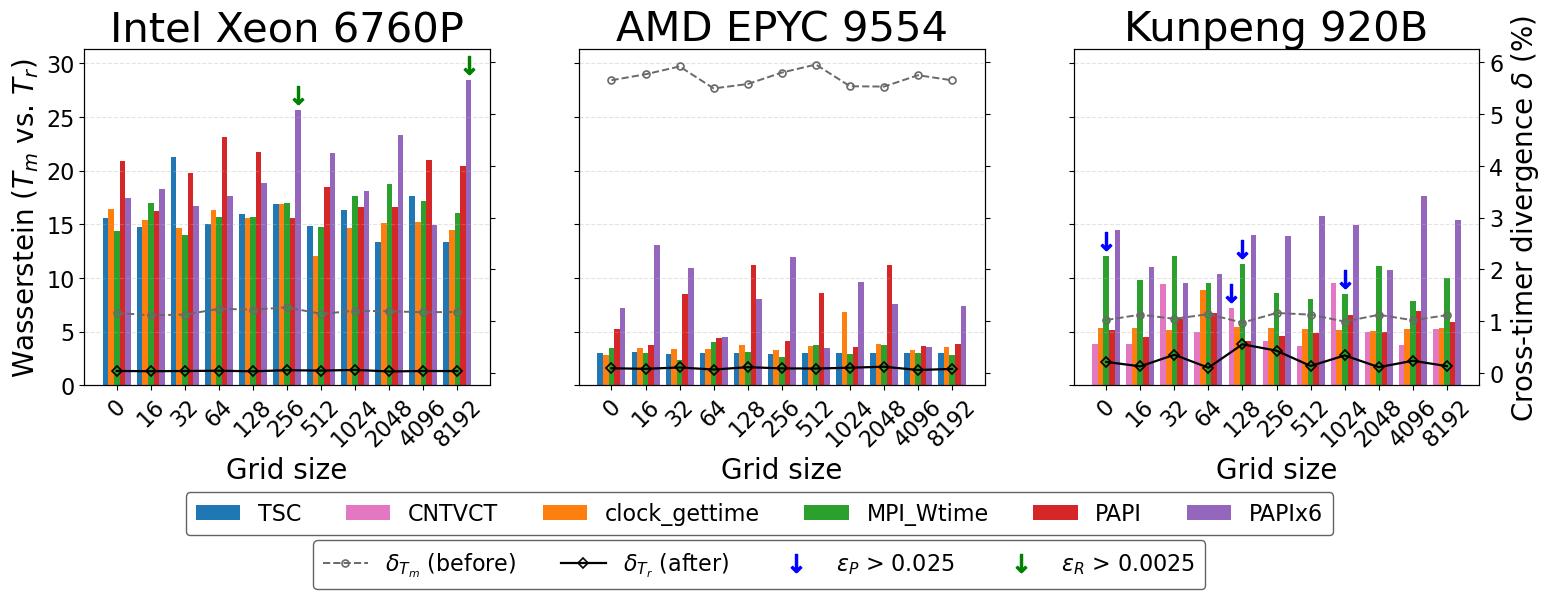

[WD / divergence Tm->Tr + eps]  tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  nsampRatio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvct'}
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_ratio0.8_wd_div_eper.png


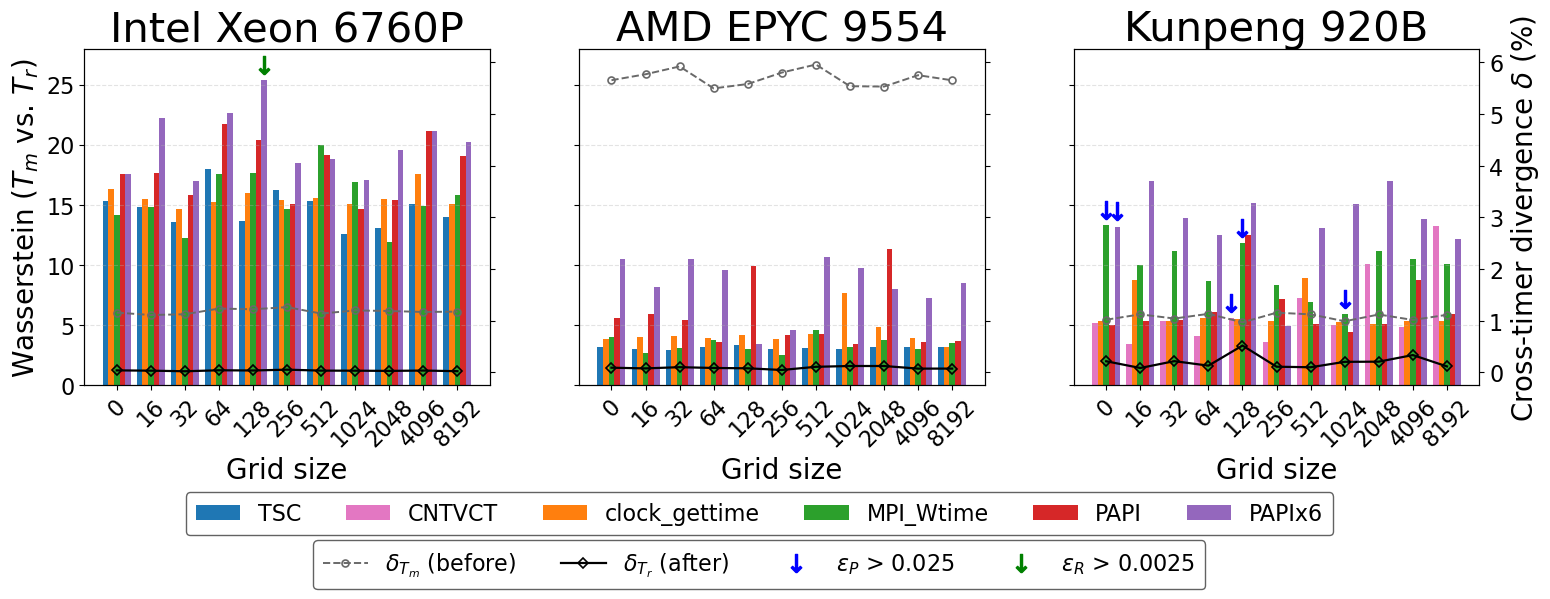

In [6]:
# Cross-timer divergence before (T_m) / after (T_r) + ep/er threshold indicators (tvkern)
# divergence delta = mean_t WD(timer, ref) / mean(ref measured time);  ref: x86->tsc, ARM->cntvct.
# reduction = (sum WD_tm - sum WD_tr) / sum WD_tm  (deviation reduction ratio; column only).
from scipy.stats import wasserstein_distance
from matplotlib.lines import Line2D

REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvct'}

# ---- thresholds (tune here) ----
EP_THRESHOLD = 0.025   # eps_P over this -> flag (paper nominal 0.3; lowered to match tvkern data scale)
ER_THRESHOLD = 0.0025  # eps_R over this -> flag (paper nominal 0.1; lowered to match tvkern data scale)

# ---- fonts (tune by hand) ----
TITLE_FONTSIZE = 30
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16
ARROW_FONTSIZE = 13
# legend vertical offsets (more negative = lower); timer legend above, divergence legend below
TIMER_LEGEND_Y = 0.00
DIV_LEGEND_Y = -0.1


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Cross-timer divergence before (TM) and after (TR), plus deviation reduction ratio.
    delta = mean over non-ref timers of WD(timer, ref) / mean(ref measured time); same base
    for before/after so the two levels are comparable. reduction = (sum_tm - sum_tr)/sum_tm."""
    rows = []
    for gv, g in src.groupby(group_keys):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref['tm_seq'])
            d_tr = _wd_seq(r['tr_seq'], ref['tr_seq'])
            if np.isfinite(d_tm):
                tm_ds.append(d_tm)
            if np.isfinite(d_tr):
                tr_ds.append(d_tr)
        s_tm = float(np.sum(tm_ds)) if tm_ds else np.nan
        s_tr = float(np.sum(tr_ds)) if tr_ds else np.nan
        gd['reduction'] = (s_tm - s_tr) / s_tm if (np.isfinite(s_tm) and s_tm > 0) else np.nan
        if np.isfinite(base) and base > 0:
            gd['d_before'] = (np.mean(tm_ds) / base) if tm_ds else np.nan
            gd['d_after'] = (np.mean(tr_ds) / base) if tr_ds else np.nan
        else:
            gd['d_before'] = gd['d_after'] = np.nan
        rows.append(gd)
    return pd.DataFrame(rows)


def _flag_color(ep_v, er_v):
    ep_hi = np.isfinite(ep_v) and ep_v > EP_THRESHOLD
    er_hi = np.isfinite(er_v) and er_v > ER_THRESHOLD
    if ep_hi and er_hi:
        return 'red'
    if ep_hi:
        return 'blue'
    if er_hi:
        return 'green'
    return None


metric_bar = 'wd'

for ratio, ratio_df in df.groupby('ratio', sort=True):
    plot_df = ratio_df.copy()
    plot_df['size_str'] = plot_df['size'].astype(str)
    size_order = [str(x) for x in sorted(plot_df['size'].unique())]
    plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

    div_df = divergence_table(plot_df, ['kernel', 'host', 'size', 'ratio'])

    hosts = [host for host in HOST_ORDER if host in set(plot_df['host'])]
    if not hosts:
        continue
    refs = {HOST_LABELS.get(h, h): REF_TIMER_BY_HOST.get(h) for h in hosts}
    print(f'[WD / divergence Tm->Tr + eps]  tvkern  {SHUFFLE_LABEL}  nsampRatio={ratio:g}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}  ref_by_host={refs}')

    gmax = np.nanmax(plot_df[metric_bar].to_numpy(dtype=float)) if len(plot_df) else 1.0
    if not np.isfinite(gmax) or gmax <= 0:
        gmax = 1.0
    arrow_dy = 0.05 * gmax

    fig, axes = plt.subplots(1, len(hosts), figsize=(6.0 * len(hosts), 4.8), sharey=True, constrained_layout=False)
    axes = np.atleast_1d(axes)

    bar_handles = {}          # keyed by timer -> handle, for ordered legend
    right_axes = []
    before_handle = after_handle = None
    any_red = False
    for ax1, host in zip(axes, hosts):
        host_df = plot_df[plot_df['host'] == host].copy()
        ref_timer = REF_TIMER_BY_HOST.get(host)
        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)
        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            heights = sub[metric_bar].to_numpy(dtype=float)
            b = ax1.bar(x + offset, heights, width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))
            bar_handles.setdefault(timer, b)
            ep_arr = sub['ep'].to_numpy(dtype=float)
            er_arr = sub['er'].to_numpy(dtype=float)
            for j in range(len(size_order)):
                h = heights[j]
                if not np.isfinite(h):
                    continue
                c = _flag_color(ep_arr[j], er_arr[j])
                if c is None:
                    continue
                if c == 'red':
                    any_red = True
                ax1.plot(x[j] + offset, h + arrow_dy, marker=r'$\downarrow$', linestyle='None',
                         color=c, markersize=ARROW_FONTSIZE, markeredgewidth=1.0, zorder=6, clip_on=False)

        ax1.set_title(HOST_LABELS.get(host, host), fontsize=TITLE_FONTSIZE)
        ax1.set_xlabel('Grid size', fontsize=AXIS_LABEL_FONTSIZE)
        # x ticks: horizontal, with the ref timer's (tsc/cntvct) TM p25/p75 on a second line
        xticklabels = []
        for s in size_order:
            rr = host_df[(host_df['timer'] == ref_timer) & (host_df['size'] == int(s))]
            if len(rr) and rr.iloc[0]['tm_seq'] is not None:
                seq = np.asarray(rr.iloc[0]['tm_seq'], dtype=float)
                p25, p75 = np.quantile(seq, 0.25), np.quantile(seq, 0.75)
                # xticklabels.append(f'{s}\n({p25:.0f}/{p75:.0f})')
                xticklabels.append(f'{s}')
            else:
                xticklabels.append(f'{s}')
        ax1.set_xticks(x)
        ax1.set_xticklabels(xticklabels, rotation=45, fontsize=TICK_FONTSIZE)
        ax1.grid(axis='y', linestyle='--', alpha=0.35)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        if ax1 is axes[0]:
            ax1.set_ylabel(r'Wasserstein ($T_m$ vs. $T_r$)', fontsize=AXIS_LABEL_FONTSIZE)

        ax2 = ax1.twinx()
        right_axes.append(ax2)
        dh = div_df[div_df['host'] == host]
        db = dh.groupby('size')['d_before'].mean()
        da = dh.groupby('size')['d_after'].mean()
        before_vals = [100.0 * db.get(int(s), np.nan) for s in size_order]
        after_vals = [100.0 * da.get(int(s), np.nan) for s in size_order]
        lb, = ax2.plot(x, before_vals, marker='o', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='dimgray', linestyle='--', linewidth=1.4)
        la, = ax2.plot(x, after_vals, marker='D', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='black', linestyle='-', linewidth=1.6)
        before_handle, after_handle = lb, la
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    # share the right-axis (divergence) scale across hosts, label only the rightmost
    rlims = [ax.get_ylim() for ax in right_axes]
    if rlims:
        rylim = (min(lo for lo, hi in rlims), max(hi for lo, hi in rlims))
        for j, ax in enumerate(right_axes):
            ax.set_ylim(rylim)
            if j == len(right_axes) - 1:
                ax.set_ylabel(r'Cross-timer divergence $\delta$ (%)', fontsize=AXIS_LABEL_FONTSIZE)
            else:
                ax.set_yticklabels([])

    # timer legend (ordered by timer_sort_key), placed at the bottom
    ordered_timers = sorted(bar_handles, key=timer_sort_key)
    fig.legend([bar_handles[t] for t in ordered_timers], [timer_label(t) for t in ordered_timers],
               ncol=min(6, max(1, len(ordered_timers))), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, TIMER_LEGEND_Y),
               frameon=True, framealpha=0.95, edgecolor='0.35', borderpad=0.45)

    # divergence legend (below): delta lines + eps arrows (+both only if drawn)
    arrow_proxies = [
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='blue', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_P$ > {EP_THRESHOLD:g}'),
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='green', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_R$ > {ER_THRESHOLD:g}'),
    ]
    if any_red:
        arrow_proxies.append(Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='red', markersize=ARROW_FONTSIZE, label='both'))
    div_handles = [before_handle, after_handle] + arrow_proxies
    div_labels = [r'$\delta_{T_m}$ (before)', r'$\delta_{T_r}$ (after)'] + [p.get_label() for p in arrow_proxies]
    fig.legend(div_handles, div_labels, ncol=min(5, len(div_labels)), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, DIV_LEGEND_Y),
               frameon=True, framealpha=0.95, edgecolor='0.35', borderpad=0.45)
    fig.subplots_adjust(bottom=0.20, top=0.90, wspace=0.22)

    if SAVE_FIG:
        for (kernel,), _g in plot_df.groupby(['kernel']):
            out = OUT_DIR / f'{kernel}_dsub_{SHUFFLE_LABEL}_ratio{ratio:g}_wd_div_eper.png'
            fig.savefig(out, dpi=220, bbox_inches='tight')
            print(out)
            break
    plt.show()

# TM/TR CDF plots


[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=0  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size0_ratio0.5_tm_tr_mark.png


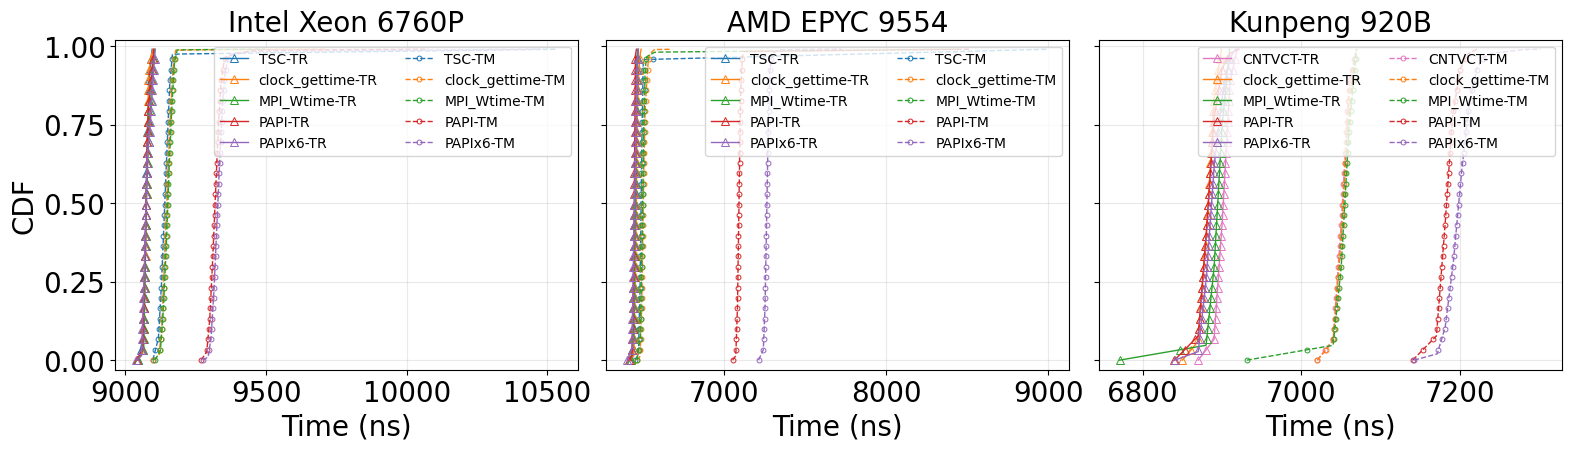

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=16  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size16_ratio0.5_tm_tr_mark.png


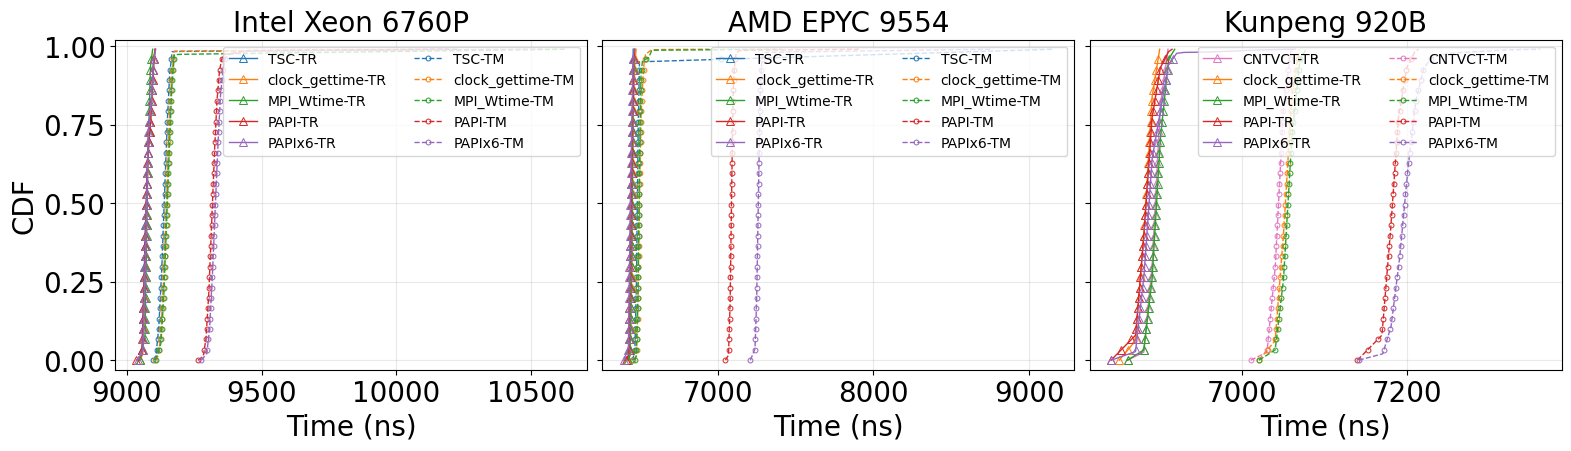

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=32  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size32_ratio0.5_tm_tr_mark.png


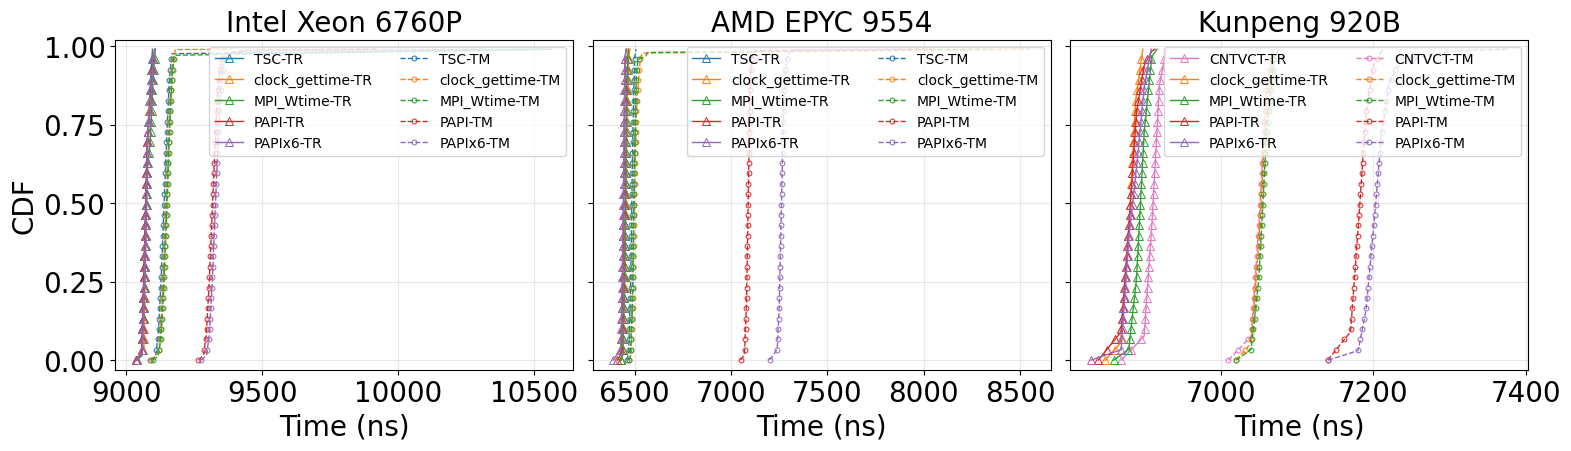

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=64  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.5_tm_tr_mark.png


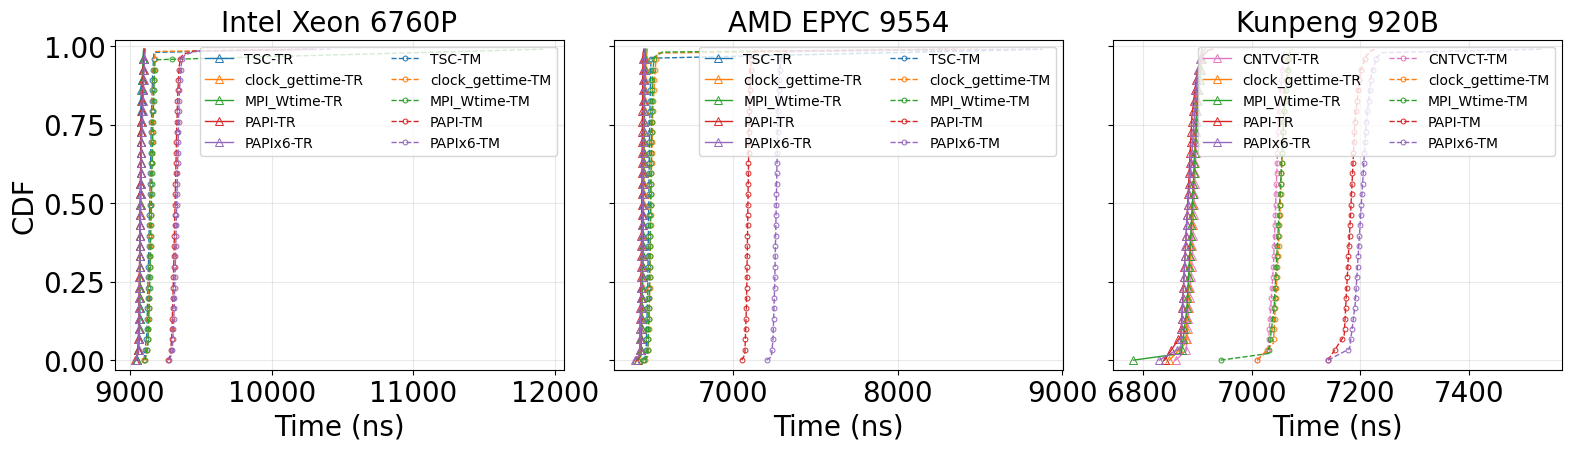

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=512  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_mark.png


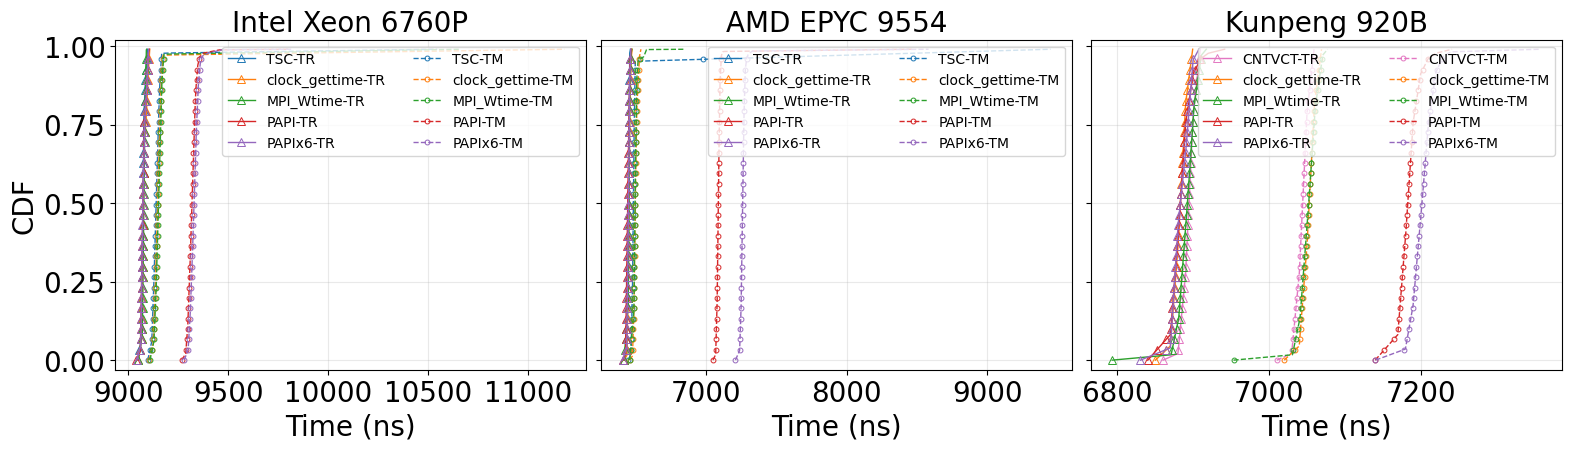

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=2048  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_mark.png


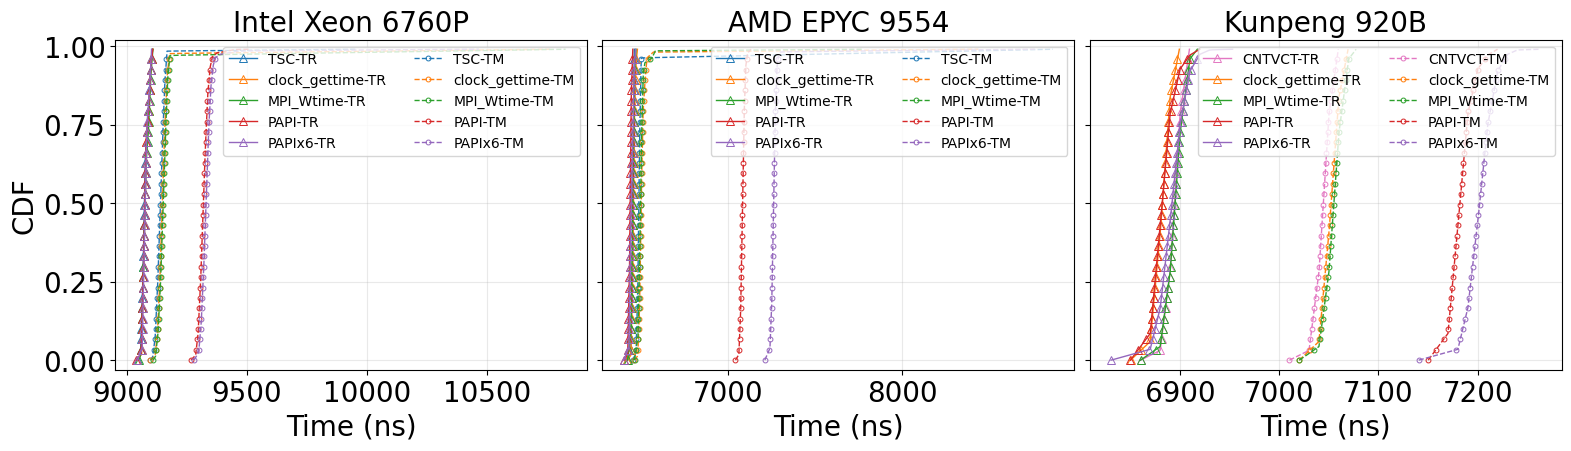

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=4096  ratio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size4096_ratio0.5_tm_tr_mark.png


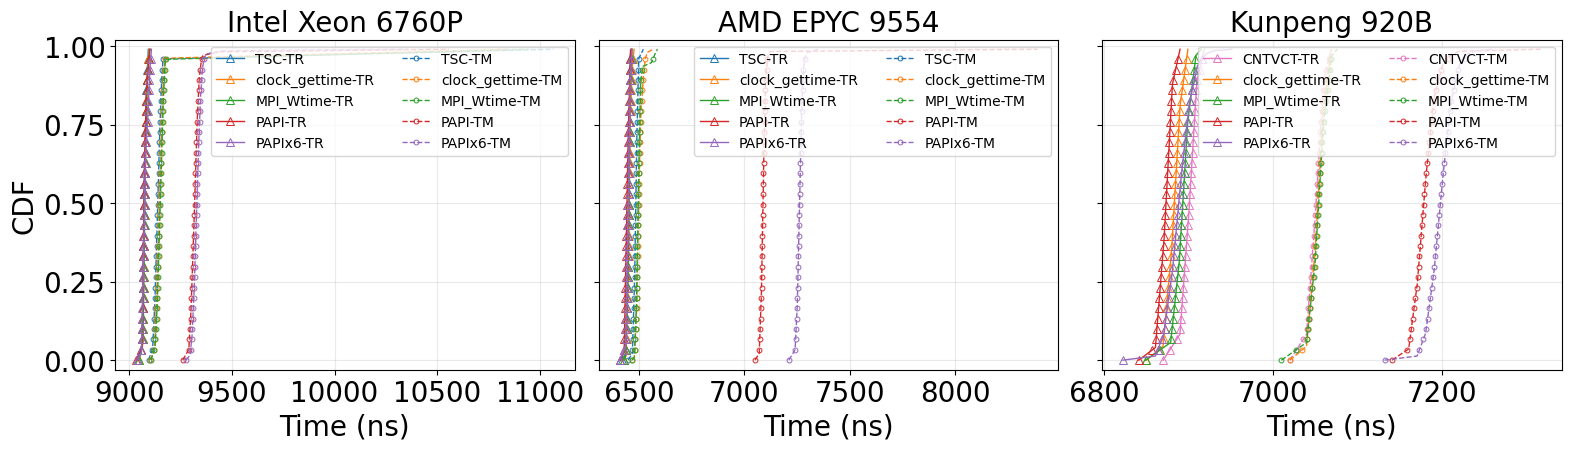

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=0  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size0_ratio0.8_tm_tr_mark.png


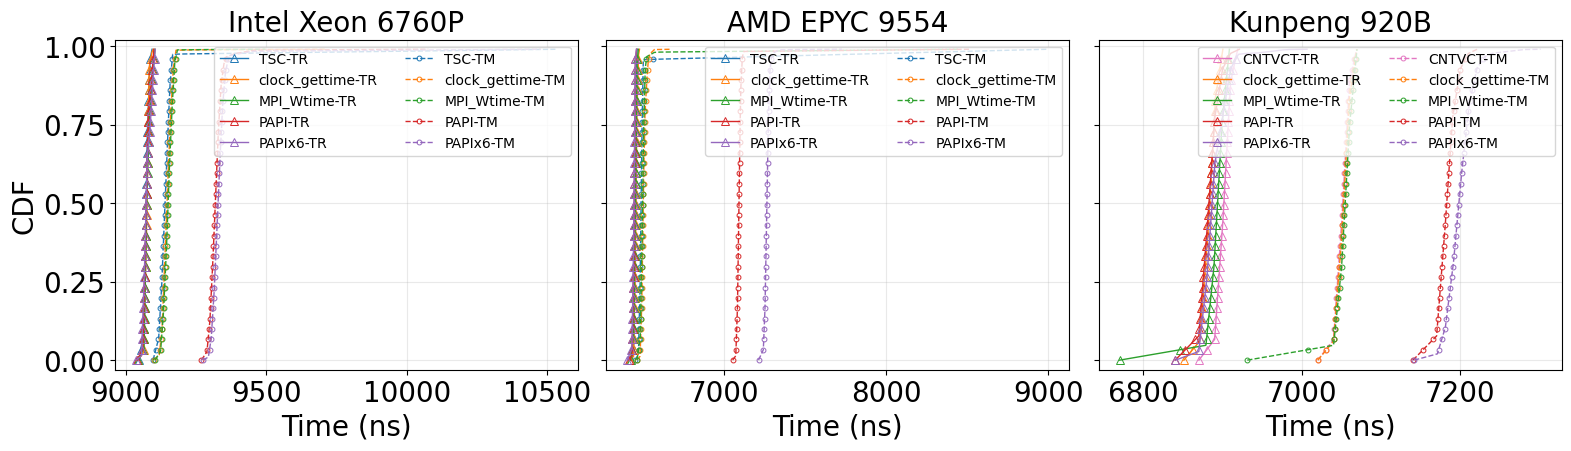

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=16  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size16_ratio0.8_tm_tr_mark.png


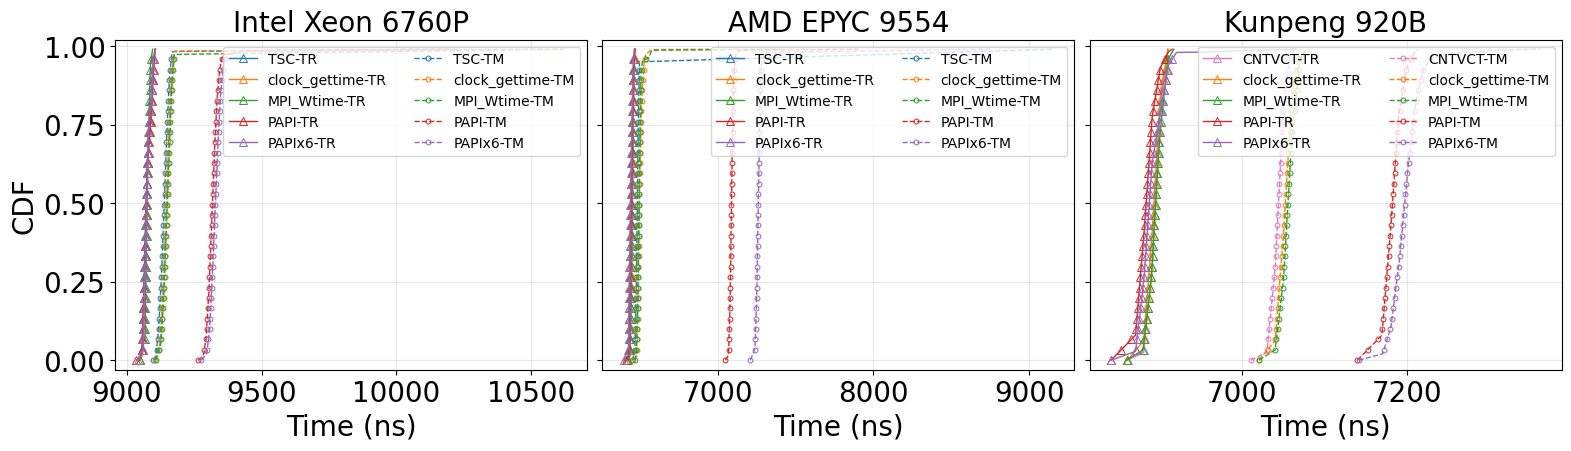

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=32  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size32_ratio0.8_tm_tr_mark.png


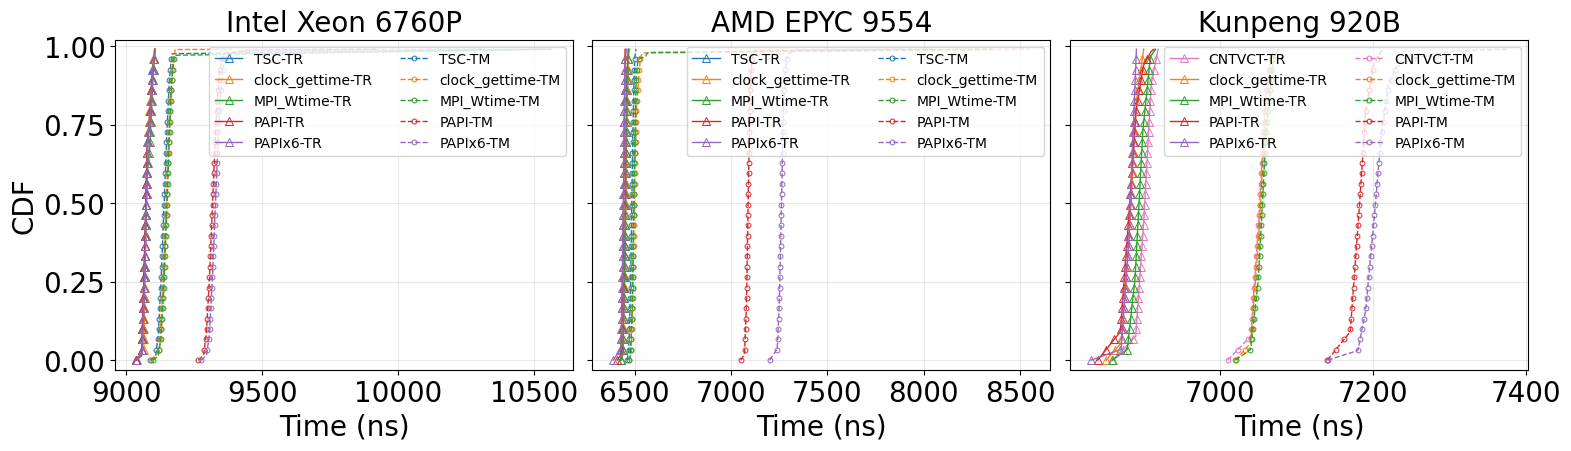

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=64  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.8_tm_tr_mark.png


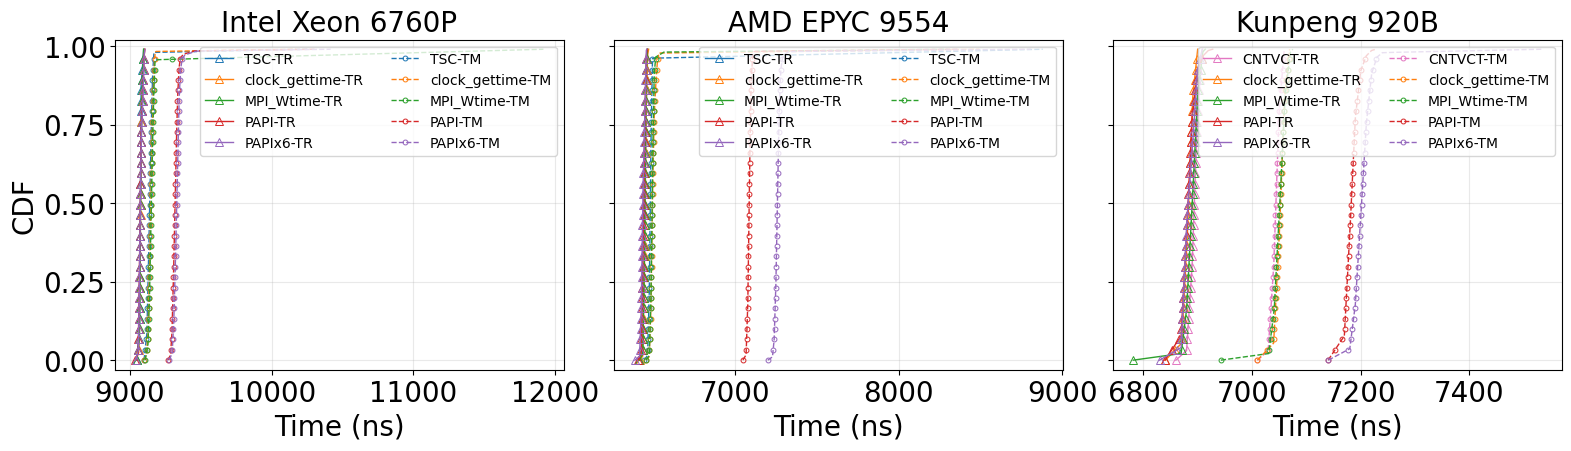

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=512  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.8_tm_tr_mark.png


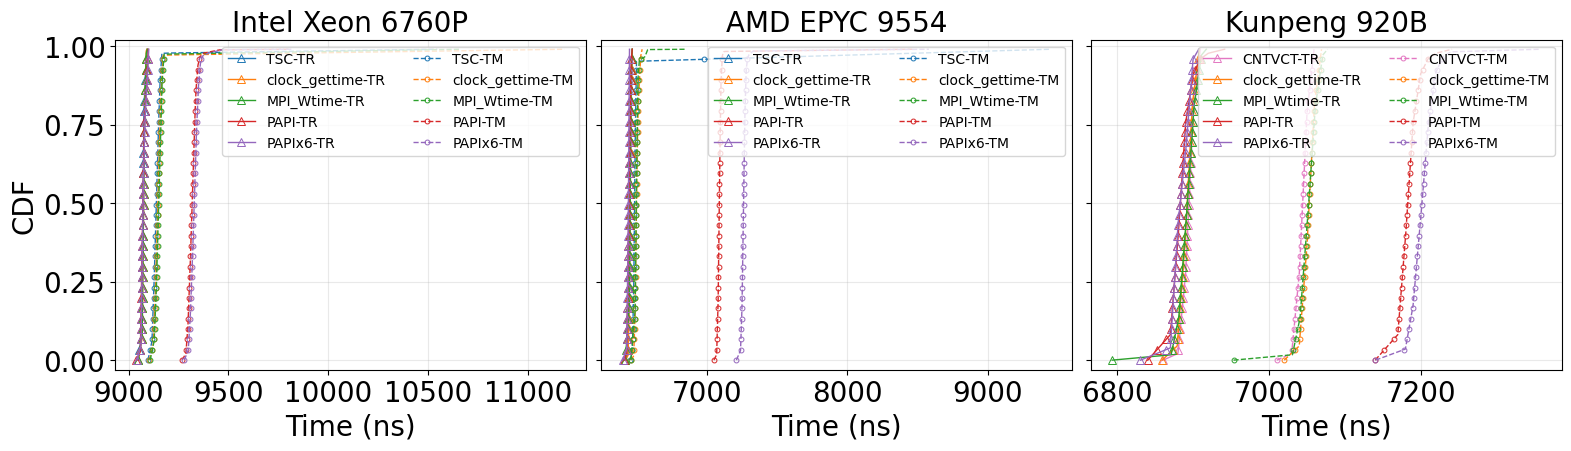

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=2048  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.8_tm_tr_mark.png


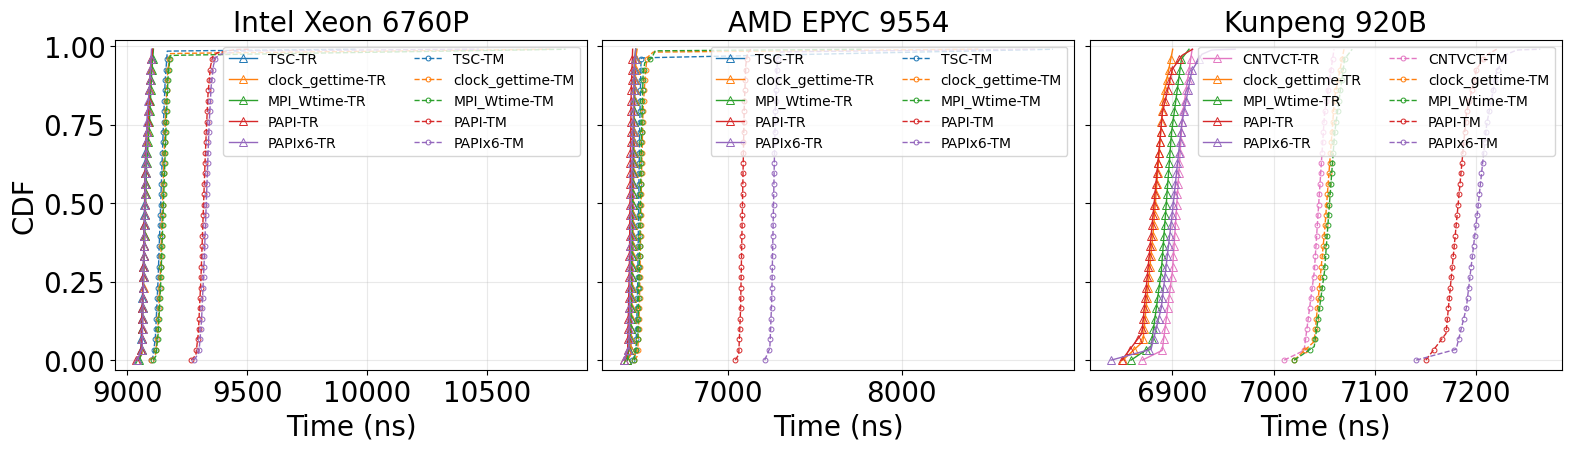

[FILT CDF]  kernel=tvkern  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=4096  ratio=0.8  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0615_tvkern_dsub/tvkern_dsub_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size4096_ratio0.8_tm_tr_mark.png


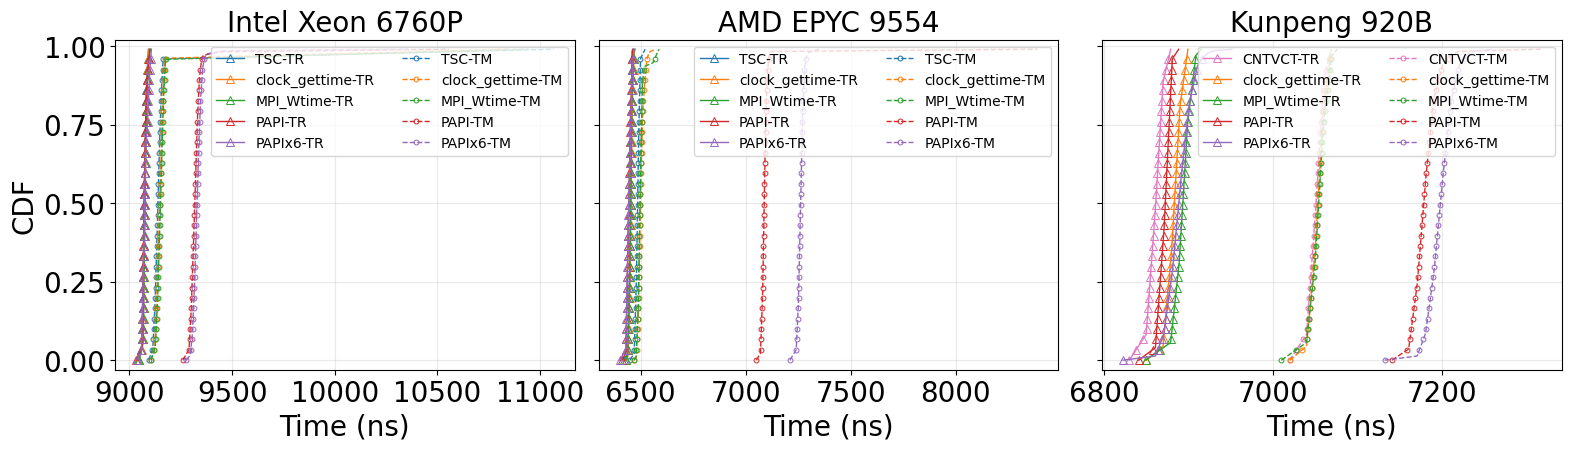

In [7]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 20
FILT_LABEL_FONTSIZE  = 20
FILT_TICK_FONTSIZE   = 20
FILT_LEGEND_FONTSIZE = 10


PLOT_SIZES = [0,16, 32, 64, 512,  2048, 4096,]

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for ratio in sorted(df['ratio'].dropna().unique()):
    for size in PLOT_SIZES:
        plot_df = df[(df['ratio'] == ratio) & (df['size'] == size)]
        if plot_df.empty:
            continue

        for (kernel, np_val), group_all in plot_df.groupby(['kernel', 'np'], sort=True):
            hosts = [host for host in HOST_ORDER if host in set(group_all['host'])]
            if not hosts:
                continue
            print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  ratio={ratio:g}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
            fig, axes = plt.subplots(1, len(hosts), figsize=(5.2 * len(hosts), 4.4), sharey=True, constrained_layout=True)
            axes = np.atleast_1d(axes)

            for ax, host in zip(axes, hosts):
                group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))
                for _, row in group.iterrows():
                    timer = row['timer']
                    color = TIMER_COLORS.get(timer)
                    label = timer_label(timer)

                    if row['tm_seq'] is None or row['tr_seq'] is None:
                        continue

                    tm_x, tm_y = seq_ecdf(row['tm_seq'])
                    tr_x, tr_y = seq_ecdf(row['tr_seq'])

                    tm_me = max(1, len(tm_x) // 30)
                    tr_me = max(1, len(tr_x) // 30)

                    ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=7, markerfacecolor='none', markeredgewidth=0.7)
                    ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=6, markerfacecolor='none', markeredgewidth=0.7)

                ax.set_title(HOST_LABELS.get(host, host), fontsize=FILT_TITLE_FONTSIZE)
                ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
                ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
                ax.grid(True, alpha=0.28)
                ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
                if ax is axes[0]:
                    ax.set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)
                oh, ol = _ordered_tr_tm(ax)
                if oh:
                    ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

            if SAVE_FIG:
                out = OUT_DIR / f'{kernel}_dsub_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{ratio:g}_tm_tr_mark.png'
                fig.savefig(out, dpi=220, bbox_inches='tight')
                print(out)
            plt.show()


In [8]:
df.join(div_df, lsuffix="_left", rsuffix="_right",how='left').sort_values(['reduction'],ascending=False)[['host_left','size_left','kernel_left','ep','er','reduction']].loc[:1]

,host_left,size_left,kernel_left,ep,er,reduction
16,c920bn3,16,tvkern,0.018326,0.000486,0.991794
20,c920bn3,32,tvkern,0.018357,0.000726,0.987109
21,c920bn3,32,tvkern,0.006062,0.001343,0.986810
12,c920bn3,16,tvkern,0.006988,0.000631,0.986403
15,c920bn3,16,tvkern,0.018357,0.001240,0.985661
14,c920bn3,16,tvkern,0.002026,0.001388,0.984221
11,c920bn3,16,tvkern,0.018326,0.000542,0.983766
13,c920bn3,16,tvkern,0.016729,0.001528,0.982776
17,c920bn3,16,tvkern,0.006988,0.000750,0.981692
24,c920bn3,32,tvkern,0.001225,0.001710,0.979524


In [9]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.025 and er <= 0.0025):
  tvkern (tvkern): [16, 32, 64, 512, 2048, 4096]


In [10]:
(df.groupby(['ratio', 'size'])['timer']
   .nunique()
   .unstack('ratio')
   .fillna(0)
   .astype(int))


ratio,0.5,0.8
size,,
0,6,6
16,6,6
32,6,6
64,6,6
128,6,6
256,6,6
512,6,6
1024,6,6
2048,6,6


In [11]:
# Per-ratio: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for ratio in sorted(df['ratio'].dropna().unique()):
    rdf = df[df['ratio'] == ratio]
    good = []
    for size, sdf in rdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  nsampRatio={ratio:g}: {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.025 and er <= 0.0025):
  nsampRatio=0.5: [16, 32, 64, 512, 2048, 4096]
  nsampRatio=0.8: [16, 32, 64, 256, 512, 2048, 4096, 8192]
